In [ ]:
#predicting house price using area feature using linear regression

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [ ]:
#loading the dataset
df=pd.read_csv('/root/House Prices.csv')
print(df.head())

      price  area  bedrooms  ...  parking  prefarea furnishingstatus
0  13300000  7420         4  ...        2       yes        furnished
1  12250000  8960         4  ...        3        no        furnished
2  12250000  9960         3  ...        2       yes   semi-furnished
3  12215000  7500         4  ...        3       yes        furnished
4  11410000  7420         4  ...        2        no        furnished

[5 rows x 13 columns]


In [ ]:
df=df.dropna() #remove null values

In [ ]:
#using area as input feature to predict price
X=df[['area']]  #independent variable as 2d
Y=df['price']  #dependent variable
#print dimensions of X & Y
print(X.shape)
print(Y.shape)

(545, 1)
(545,)


In [ ]:
#creating the model
model=LinearRegression()
model.fit(X,Y)

LinearRegression()

In [ ]:
#PRINT EQUATION PARAMETERS
print("slope : m : ",model.coef_[0])
print("intercept : c : ",model.intercept_)

slope : m :  461.97489427278344
intercept : c :  2387308.48239643


In [ ]:
#predict
y_pred=model.predict(X)

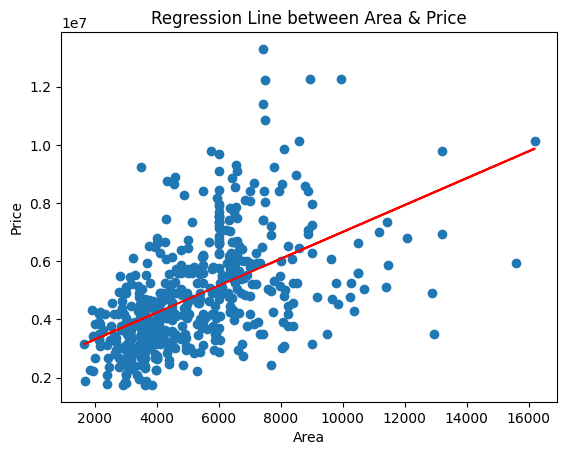

In [ ]:
#plot regression line

plt.scatter(X,Y)
plt.plot(X,y_pred,color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Regression Line between Area & Price")
plt.show()

In [ ]:
#MEAN ABSOLUTE ERROR FOR ABOVE SIMPLE LR
mae=mean_absolute_error(Y,y_pred)
print("MEAN ABS ERROR : ",mae)
r2=r2_score(Y,y_pred)
print(r2)

MEAN ABS ERROR :  1172305.5113148908
0.2872931546811469


In [ ]:
df=pd.get_dummies(df,drop_first=True,dtype=int)
print(df)

        price  ...  furnishingstatus_unfurnished
0    13300000  ...                             0
1    12250000  ...                             0
2    12250000  ...                             0
3    12215000  ...                             0
4    11410000  ...                             0
..        ...  ...                           ...
540   1820000  ...                             1
541   1767150  ...                             0
542   1750000  ...                             1
543   1750000  ...                             0
544   1750000  ...                             1

[545 rows x 14 columns]


In [ ]:
#SEPARATE FEATURES AND TARGET
X=df.drop('price',axis=1)
Y=df['price']

#TRAIN TEST SPLIT
model=LinearRegression()
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
y_pred2=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred2)
print(mae)

970043.4039201636


In [ ]:
r2=r2_score(y_test,y_pred2)
print(r2)

0.6529242642153184


In [ ]:
Y.shape, y_pred.shape

((545,), (545,))